Model Step 1 — Load data, time-based split

In [1]:
import numpy as np
import pandas as pd

In [2]:
# Model Step 1: load model-ready data + time-based train/test split
mdf = pd.read_parquet("model_ready.parquet")

# TIME-BASED split (never random): train on Jan–Sep, test on Oct–Dec 2016
TRAIN_END  = "2016-09-30 23:00:00"
TEST_START = "2016-10-01 00:00:00"

train = mdf[mdf["timestamp"] <= TRAIN_END].copy()
test  = mdf[mdf["timestamp"] >= TEST_START].copy()

print("train :", train.shape, "| dates", train["timestamp"].min(), "->", train["timestamp"].max())
print("test  :", test.shape,  "| dates", test["timestamp"].min(),  "->", test["timestamp"].max())
print("test fraction:", round(len(test) / len(mdf), 3))

train : (8234130, 14) | dates 2016-01-08 00:00:00 -> 2016-09-30 23:00:00
test  : (2956053, 14) | dates 2016-10-01 00:00:00 -> 2016-12-31 23:00:00
test fraction: 0.264


Model Step 2 — The baseline

In [3]:
# Model Step 2: metrics + seasonal-naive baseline
def rmse(y, p):  return np.sqrt(np.mean((y - p) ** 2))
def mae(y, p):   return np.mean(np.abs(y - p))
def rmsle(y, p):
    p = np.clip(p, 0, None)                       # no negative predictions
    return np.sqrt(np.mean((np.log1p(y) - np.log1p(p)) ** 2))
def mape(y, p):                                   # exclude zeros to avoid /0
    m = y > 0
    return np.mean(np.abs((y[m] - p[m]) / y[m])) * 100

y_test = test["meter_reading"].values

# baseline prediction = value from same hour last week
baseline_pred = test["lag_168h"].values

results = {}
results["Seasonal-naive"] = {
    "RMSE":  rmse(y_test, baseline_pred),
    "MAE":   mae(y_test, baseline_pred),
    "MAPE%": mape(y_test, baseline_pred),
    "RMSLE": rmsle(y_test, baseline_pred),
}
print("Seasonal-naive baseline:")
for k, v in results["Seasonal-naive"].items():
    print(f"  {k:6}: {v:.3f}")

Seasonal-naive baseline:
  RMSE  : 104.951
  MAE   : 18.631
  MAPE% : 70.279
  RMSLE : 0.407


Model Step 3 — Train the LightGBM model

In [4]:
# Model Step 3: train LightGBM
import lightgbm as lgb

features = ["hour", "weekday", "month", "is_weekend",
            "lag_24h", "lag_168h", "roll_mean_24h",
            "air_temperature", "dew_temperature",
            "log_square_feet", "primary_use", "building_id"]
cat_features = ["primary_use", "building_id"]

# LightGBM reads categoricals natively — make sure both are 'category' dtype
for d in (train, test):
    d["primary_use"] = d["primary_use"].astype("category")
    d["building_id"] = d["building_id"].astype("category")

# carve a VALIDATION slice from the tail of train (Sept) — used only to
# decide when to stop training. Test stays untouched (no leakage).
fit_mask = train["timestamp"] <= "2016-08-31 23:00:00"
Xtr,  ytr  = train.loc[fit_mask,  features], np.log1p(train.loc[fit_mask,  "meter_reading"])
Xval, yval = train.loc[~fit_mask, features], np.log1p(train.loc[~fit_mask, "meter_reading"])

model = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1,
)
model.fit(
    Xtr, ytr,
    eval_set=[(Xval, yval)], eval_metric="rmse",
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)
print("\n✅ trained. best iteration:", model.best_iteration_)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.060887 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2884
[LightGBM] [Info] Number of data points in the train set: 7242668, number of used features: 12
[LightGBM] [Info] Start training from score 4.090294
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.230734	valid_0's l2: 0.053238
[200]	valid_0's rmse: 0.225131	valid_0's l2: 0.0506838
[300]	valid_0's rmse: 0.222024	valid_0's l2: 0.0492946
[400]	valid_0's rmse: 0.219998	valid_0's l2: 0.0483989
[500]	valid_0's rmse: 0.218451	valid_0's l2: 0.0477209
[600]	valid_0's rmse: 0.21

Model Step 4 — Predict on the test set & compare

In [5]:
# Model Step 4: predict on test + compare to baseline
pred_log = model.predict(test[features], num_iteration=model.best_iteration_)
lgbm_pred = np.clip(np.expm1(pred_log), 0, None)   # back to kWh, no negatives

results["LightGBM"] = {
    "RMSE":  rmse(y_test, lgbm_pred),
    "MAE":   mae(y_test, lgbm_pred),
    "MAPE%": mape(y_test, lgbm_pred),
    "RMSLE": rmsle(y_test, lgbm_pred),
}

# comparison table
comparison = pd.DataFrame(results).T[["RMSE", "MAE", "MAPE%", "RMSLE"]].round(3)
print(comparison)

# % improvement in RMSLE over the baseline
imp = (1 - results["LightGBM"]["RMSLE"] / results["Seasonal-naive"]["RMSLE"]) * 100
print(f"\nLightGBM improves RMSLE by {imp:.1f}% over the baseline")


                   RMSE     MAE   MAPE%  RMSLE
Seasonal-naive  104.951  18.631  70.279  0.407
LightGBM        164.744  16.405  24.053  0.242

LightGBM improves RMSLE by 40.7% over the baseline


In [6]:
# diagnostic: is high RMSE from big buildings or runaway predictions?
err = np.abs(y_test - lgbm_pred)
print("max actual reading:", round(float(y_test.max()), 1))
print("max predicted     :", round(float(lgbm_pred.max()), 1))

worst = np.argsort(err)[-5:][::-1]
print("\n5 worst errors:")
print(test.iloc[worst][["building_id", "timestamp", "meter_reading"]]
      .assign(predicted=lgbm_pred[worst].round(1),
              abs_error=err[worst].round(1)))


max actual reading: 19511.0
max predicted     : 6246.3

5 worst errors:
        building_id           timestamp  meter_reading  predicted  abs_error
7789277         993 2016-10-17 07:00:00        19511.0        1.1    19509.9
7789271         993 2016-10-17 01:00:00        19511.0      164.6    19346.4
7789247         993 2016-10-16 01:00:00        19511.0      253.8    19257.2
7789223         993 2016-10-15 01:00:00        19511.0     1257.8    18253.2
7791023         993 2016-12-29 01:00:00        17999.0       42.8    17956.2


In [7]:
# detect frozen-meter runs: same nonzero value repeated >= 24 consecutive hours
tmp = mdf.sort_values(["building_id", "timestamp"])
changed = tmp["meter_reading"] != tmp.groupby("building_id")["meter_reading"].shift()
run_id  = changed.cumsum()
run_len = tmp.groupby(run_id)["meter_reading"].transform("size")

frozen = (run_len >= 24) & (tmp["meter_reading"] > 0)
print("frozen rows :", int(frozen.sum()), f"({frozen.mean()*100:.2f}% of data)")
print("buildings   :", tmp.loc[frozen, "building_id"].nunique())


frozen rows : 602396 (5.38% of data)
buildings   : 257


In [8]:
# re-evaluate EXISTING predictions with frozen test rows excluded
keep_test = ~frozen.reindex(test.index).fillna(False).values   # True = keep (not frozen)

y2  = y_test[keep_test]
lg2 = lgbm_pred[keep_test]
bs2 = baseline_pred[keep_test]
print(f"test rows: {len(y_test):,} -> {len(y2):,} (removed {(~keep_test).sum():,} frozen)")

clean_results = {
    "Seasonal-naive": {"RMSE": rmse(y2, bs2), "MAE": mae(y2, bs2),
                       "MAPE%": mape(y2, bs2), "RMSLE": rmsle(y2, bs2)},
    "LightGBM":       {"RMSE": rmse(y2, lg2), "MAE": mae(y2, lg2),
                       "MAPE%": mape(y2, lg2), "RMSLE": rmsle(y2, lg2)},
}
print(pd.DataFrame(clean_results).T[["RMSE", "MAE", "MAPE%", "RMSLE"]].round(3))


test rows: 2,956,053 -> 2,823,304 (removed 132,749 frozen)
                   RMSE     MAE   MAPE%  RMSLE
Seasonal-naive  100.462  18.448  37.164  0.397
LightGBM        163.788  16.260  16.261  0.237


In [9]:
# Lock in final result: remove frozen bad-data rows, retrain, re-evaluate consistently
clean_mdf = tmp.loc[~frozen].reset_index(drop=True)
print("rows:", f"{len(mdf):,} -> {len(clean_mdf):,}")

train = clean_mdf[clean_mdf["timestamp"] <= TRAIN_END].copy()
test  = clean_mdf[clean_mdf["timestamp"] >= TEST_START].copy()
for d in (train, test):
    d["primary_use"] = d["primary_use"].astype("category")
    d["building_id"] = d["building_id"].astype("category")

y_test = test["meter_reading"].values
baseline_pred = test["lag_168h"].values

fit_mask = train["timestamp"] <= "2016-08-31 23:00:00"
Xtr, ytr   = train.loc[fit_mask, features],  np.log1p(train.loc[fit_mask,  "meter_reading"])
Xval, yval = train.loc[~fit_mask, features], np.log1p(train.loc[~fit_mask, "meter_reading"])

model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=63,
                          subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
model.fit(Xtr, ytr, eval_set=[(Xval, yval)], eval_metric="rmse",
          categorical_feature=cat_features,
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(200)])

lgbm_pred = np.clip(np.expm1(model.predict(test[features], num_iteration=model.best_iteration_)), 0, None)

results = {
 "Seasonal-naive": {"RMSE": rmse(y_test, baseline_pred), "MAE": mae(y_test, baseline_pred),
                    "MAPE%": mape(y_test, baseline_pred), "RMSLE": rmsle(y_test, baseline_pred)},
 "LightGBM":       {"RMSE": rmse(y_test, lgbm_pred), "MAE": mae(y_test, lgbm_pred),
                    "MAPE%": mape(y_test, lgbm_pred), "RMSLE": rmsle(y_test, lgbm_pred)},
}
comparison = pd.DataFrame(results).T[["RMSE", "MAE", "MAPE%", "RMSLE"]].round(3)
print(comparison)


rows: 11,190,183 -> 10,587,787
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056227 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2818
[LightGBM] [Info] Number of data points in the train set: 6824665, number of used features: 12
[LightGBM] [Info] Start training from score 4.153249
Training until validation scores don't improve for 50 rounds
[200]	valid_0's rmse: 0.221848	valid_0's l2: 0.0492164
[400]	valid_0's rmse: 0.21771	valid_0's l2: 0.0473978
[600]	valid_0's rmse: 0.215629	valid_0's l2: 0.046496
[800]	valid_0's rmse: 0.213848	valid_0's l2: 0.0457309
[1000]	valid_0's rmse: 0.21305	valid_0's l2: 0.0453

In [10]:
from sklearn.metrics import r2_score

r2_raw = r2_score(y_test, lgbm_pred)
r2_log = r2_score(np.log1p(y_test), np.log1p(lgbm_pred))   # fairer for skewed data
acc_like = 100 - results["LightGBM"]["MAPE%"]

print(f"R² (raw kWh) : {r2_raw:.3f}   (squared-error based -> hurt by a few giant buildings)")
print(f"R² (log)     : {r2_log:.3f}   (fairer for skewed data; matches how we trained)")
print(f"~Accuracy    : {acc_like:.1f}%   (100 - MAPE, intuitive but rough)")


R² (raw kWh) : 0.813   (squared-error based -> hurt by a few giant buildings)
R² (log)     : 0.973   (fairer for skewed data; matches how we trained)
~Accuracy    : 83.3%   (100 - MAPE, intuitive but rough)


In [11]:
# save cleaned data + test-set forecasts for the emissions and SHAP notebooks
clean_mdf.to_parquet("model_ready_clean.parquet", index=False)

test_out = test[["building_id", "timestamp", "meter_reading", "primary_use", "month"]].copy()
test_out["prediction"] = lgbm_pred
test_out.to_parquet("test_predictions.parquet", index=False)

print("saved: model_ready_clean.parquet  (fully cleaned data)")
print("saved: test_predictions.parquet   (actual vs forecast on Oct–Dec)")


saved: model_ready_clean.parquet  (fully cleaned data)
saved: test_predictions.parquet   (actual vs forecast on Oct–Dec)


Interpretability Step 1 — Feature importance

In [12]:
import matplotlib.pyplot as plt

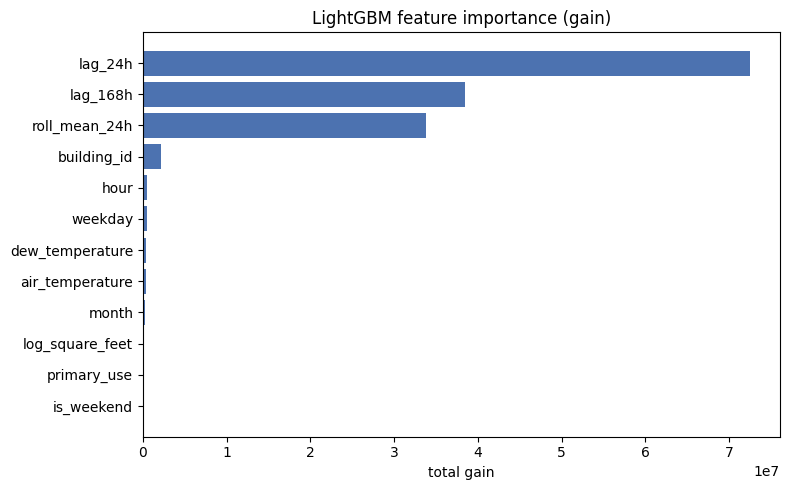

lag_24h            72445970.0
lag_168h           38462901.0
roll_mean_24h      33787490.0
building_id         2184555.0
hour                 487911.0
weekday              463418.0
dew_temperature      376500.0
air_temperature      375558.0
month                221833.0
log_square_feet      103661.0
primary_use           48949.0
is_weekend            25355.0
dtype: float64


In [13]:
# Interpretability Step 1: LightGBM feature importance (by gain)

gain = model.booster_.feature_importance(importance_type="gain")
imp = pd.Series(gain, index=features).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(imp.index, imp.values, color="#4C72B0")
plt.title("LightGBM feature importance (gain)")
plt.xlabel("total gain")
plt.tight_layout()
plt.show()

print(imp.sort_values(ascending=False).round(0))


Interpretability Step 2 — SHAP

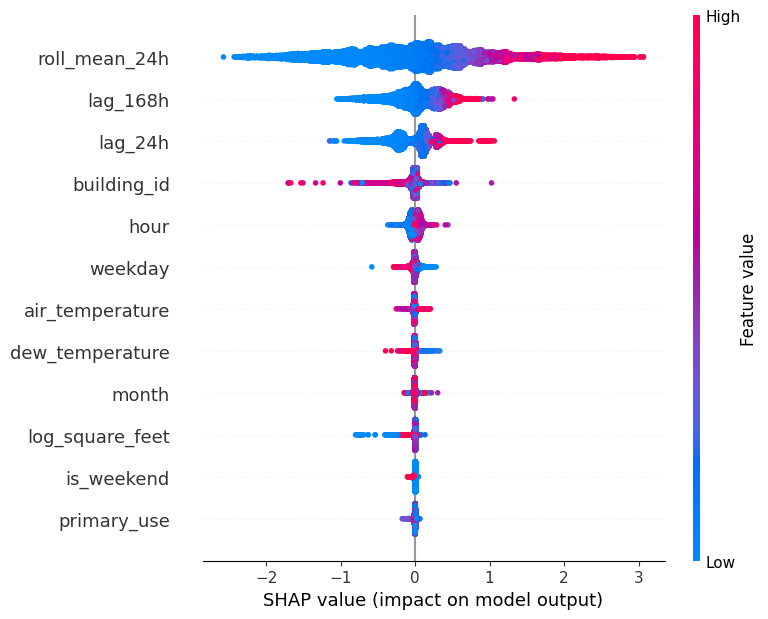

SHAP summary saved.


In [14]:
# Interpretability Step 2: SHAP summary on a sample of the test set
import shap

X_sample = test[features].sample(n=20000, random_state=42)

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# categoricals -> integer codes so the plot can colour them
X_disp = X_sample.copy()
for c in cat_features:
    X_disp[c] = X_disp[c].cat.codes

shap.summary_plot(shap_values, X_disp, show=False, max_display=12)
plt.tight_layout()
plt.show()
print("SHAP summary saved.")
